In [1]:
# 라이브러리 준비
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import classification_report, confusion_matrix

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 시각화 동작 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 학습 리소스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

사용 디바이스: cpu


In [2]:
# 학습 및 테스트 데이터 준비
transform = transforms.Compose([
    transforms.ToTensor(),                             # (28, 28) → (1, 28, 28), 0~1 정규화
    transforms.Normalize((0.1307,), (0.3081,))          # MNIST 전체 평균/표준편차
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"훈련 샘플 수 : {len(train_dataset):,}")
print(f"테스트 샘플 수: {len(test_dataset):,}")
print(f"샘플 shape   : {train_dataset[0][0].shape}")   # torch.Size([1, 28, 28]) ← 평탄화 없음


훈련 샘플 수 : 60,000
테스트 샘플 수: 10,000
샘플 shape   : torch.Size([1, 28, 28])


In [3]:
# 훈련/검증 분리 (8:2) 후 DataLoader 구성
BATCH_SIZE = 128

train_size = int(0.8 * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_ds, val_ds = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds,   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,     batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

X_batch, y_batch = next(iter(train_loader))
print(f"배치 입력 shape: {X_batch.shape}")   # (128, 1, 28, 28) ← CNN은 4D 입력을 그대로 받음


배치 입력 shape: torch.Size([128, 1, 28, 28])


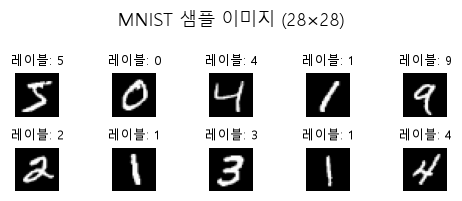

1차원 변환 후 shape: torch.Size([1, 28, 28])
1차원 변환 후 값 범위: [-0.424, 2.821]


In [4]:
# 샘플 이미지 시각화 (1차원 변환 전 원본 확인)
sample_transform = transforms.Compose([
    transforms.ToTensor(),
])
sample_ds = datasets.MNIST(root="./data", train=True, download=False, transform=sample_transform)

fig, axes = plt.subplots(2, 5, figsize=(5, 2)) # 그리기 화면을 2행 5열로 나누기 -> 각 그리기 영역 : axes
for i, ax in enumerate(axes.flat):
    img, label = sample_ds[i]
    ax.imshow(img.squeeze(), cmap="gray") # 현재 그리기 영역에 이미지 그리기 imshow, squeeze() : (1, 28, 28) => (28, 28)
    ax.set_title(f"레이블: {label}", fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST 샘플 이미지 (28×28)", fontsize=13)
plt.tight_layout()
plt.show()

print("1차원 변환 후 shape:", train_dataset[0][0].shape)   # torch.Size([784])
print("1차원 변환 후 값 범위: [{:.3f}, {:.3f}]".format(
    train_dataset[0][0].min().item(), train_dataset[0][0].max().item()
))


In [5]:
# Conv → BatchNorm → ReLU → Pool 패턴을
# 입력 채널 1(흑백), 클래스 10개(숫자 0~9)에 맞게 적용한다
class MNIST_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: (1, 28, 28) → (16, 14, 14)
            nn.Conv2d(1, 16, kernel_size=3, padding=1), # 16 : 나가는 필터 개수 (=outChanner 갯수)
            nn.BatchNorm2d(16), # 필터 개수 만큼 정규화 작업 필요함
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: (16, 14, 14) → (32, 7, 7)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128), # 완전 연결층 구성
            nn.ReLU(),
            nn.Dropout(0.3), # 과대적합 해소해서, 일반화 성능 높임
            nn.Linear(128, num_classes)
        )
    # drop out -> 유닛개수가 급격하게 변화 -> 주로 flatten 구역

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNIST_CNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 수: {total_params:,}")


MNIST_CNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
전체 파라미터 수: 207,018


In [7]:
# 학습 설계

EPOCHS = 15
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS) # 학습률 저하장치


In [9]:
# 훈련 및 평가 함수
def train_epoch(model, loader, criterion, optimizer, device):
    model.train() # dropout 활성화
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (pred.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred  = model(X)
            total_loss += criterion(pred, y).item()
            correct    += (pred.argmax(1) == y).sum().item()
            total      += y.size(0)

    return total_loss / len(loader), correct / total


In [11]:
# 훈련 실행

history  = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc = eval_epoch(model, val_loader,   criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), "mnist_cnn_best.pt")

    print(f"Epoch {epoch:>2} | Train {tr_loss:.4f}/{tr_acc:.2%} | Val {va_loss:.4f}/{va_acc:.2%}")

print(f"\n최고 검증 정확도: {best_acc:.2%}")

Epoch  1 | Train 0.0193/99.40% | Val 0.0324/98.98%
Epoch  2 | Train 0.0168/99.45% | Val 0.0332/98.99%
Epoch  3 | Train 0.0128/99.61% | Val 0.0309/99.12%
Epoch  4 | Train 0.0110/99.67% | Val 0.0303/99.15%
Epoch  5 | Train 0.0090/99.74% | Val 0.0296/99.13%
Epoch  6 | Train 0.0080/99.76% | Val 0.0292/99.15%
Epoch  7 | Train 0.0073/99.79% | Val 0.0287/99.16%
Epoch  8 | Train 0.0072/99.80% | Val 0.0287/99.12%
Epoch  9 | Train 0.0062/99.85% | Val 0.0287/99.12%
Epoch 10 | Train 0.0066/99.80% | Val 0.0287/99.11%
Epoch 11 | Train 0.0068/99.82% | Val 0.0295/99.15%
Epoch 12 | Train 0.0076/99.77% | Val 0.0298/99.17%
Epoch 13 | Train 0.0078/99.76% | Val 0.0313/99.09%
Epoch 14 | Train 0.0086/99.75% | Val 0.0318/99.13%
Epoch 15 | Train 0.0103/99.67% | Val 0.0332/99.08%

최고 검증 정확도: 99.17%


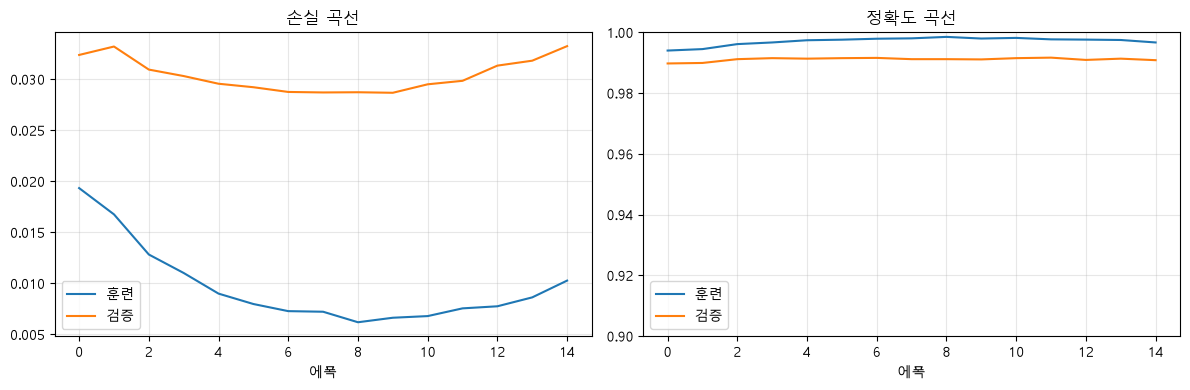

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="훈련")
axes[0].plot(history["val_loss"],   label="검증")
axes[0].set_title("손실 곡선")
axes[0].set_xlabel("에폭")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["train_acc"], label="훈련")
axes[1].plot(history["val_acc"],   label="검증")
axes[1].set_title("정확도 곡선")
axes[1].set_xlabel("에폭")
axes[1].set_ylim(0.9, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mnist_cnn_training_curve.png", dpi=100, bbox_inches="tight")
plt.show()


In [ ]:
# 모델 테스트 및 평가
model.load_state_dict(torch.load("mnist_cnn_best.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        pred = model(X.to(device)).argmax(1).cpu()
        all_preds.extend(pred.numpy())
        all_labels.extend(y.numpy())

print("=== 테스트 세트 평가 결과 ===")
print(classification_report(all_labels, all_preds,
                             target_names=[str(i) for i in range(10)]))


=== 테스트 세트 평가 결과 ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



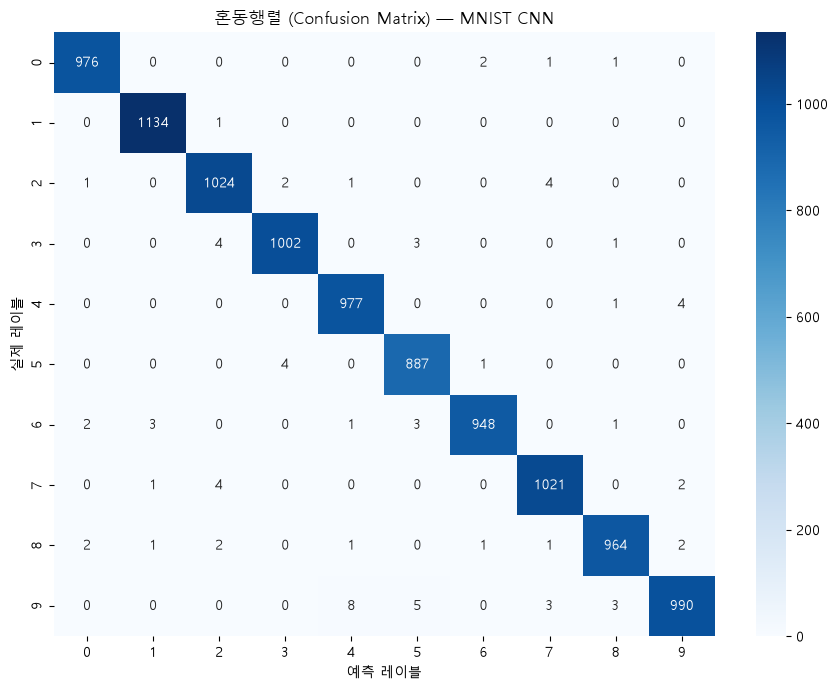

In [14]:
# 모델 테스트 및 평가 2
# 혼동행렬
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("혼동행렬 (Confusion Matrix) — MNIST CNN")
plt.xlabel("예측 레이블")
plt.ylabel("실제 레이블")
plt.tight_layout()
plt.savefig("mnist_cnn_confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()


오분류 샘플 수: 77 / 10000


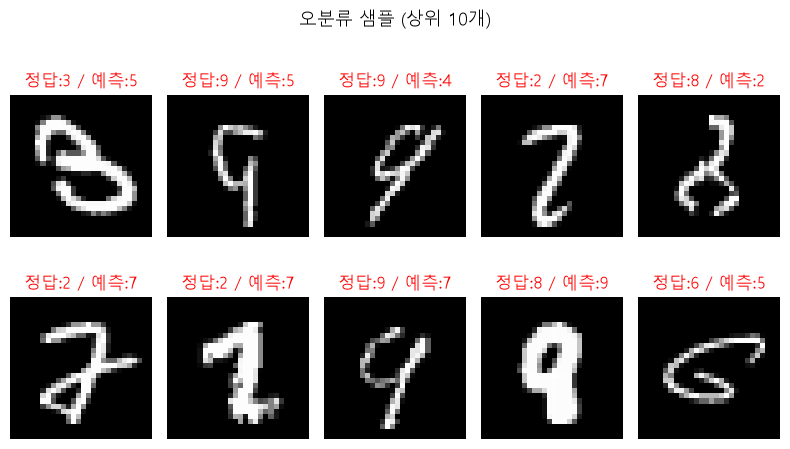

In [19]:
# 모델 테스트 및 평가 3
# 오분류 샘플 시각화
raw_test_ds = datasets.MNIST(root="./data", train=False, download=False,
                              transform=transforms.ToTensor())

errors = [(i, p, l) for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
print(f"오분류 샘플 수: {len(errors)} / {len(all_labels)}")

fig, axes = plt.subplots(2, 5, figsize=(8, 5))
for ax, (idx, pred, label) in zip(axes.flat, errors[:10]):
    img, _ = raw_test_ds[idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"정답:{label} / 예측:{pred}", color="red")
    ax.axis("off")
plt.suptitle("오분류 샘플 (상위 10개)", fontsize=13)
plt.tight_layout()
plt.savefig("mnist_cnn_errors.png", dpi=100, bbox_inches="tight")
plt.show()
